# Deep Learning Optical Flow Demo

Demonstrates deep learning optical flow methods integrated into the
`optical_flow` package:

- **RAFT** (Teed & Deng, ECCV 2020): Recurrent All Pairs Field Transforms
- **SEA-RAFT** (Wang, Lipson & Deng, ECCV 2024): Simple, Efficient, Accurate RAFT
- **WAFT** (Wang & Deng, ICLR 2026): Warping-Alone Field Transforms

All methods use the same `estimate_flow()` API as variational methods.
Requires `pip install optical_flow[deep]` for PyTorch dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time

from optical_flow import estimate_flow, flow_to_color, plot_flow
from optical_flow.evaluation.metrics import flow_angular_error
from optical_flow.io.flo_io import read_flo

%matplotlib inline

## Load RubberWhale Sequence

Image size: 584 x 388 x 3


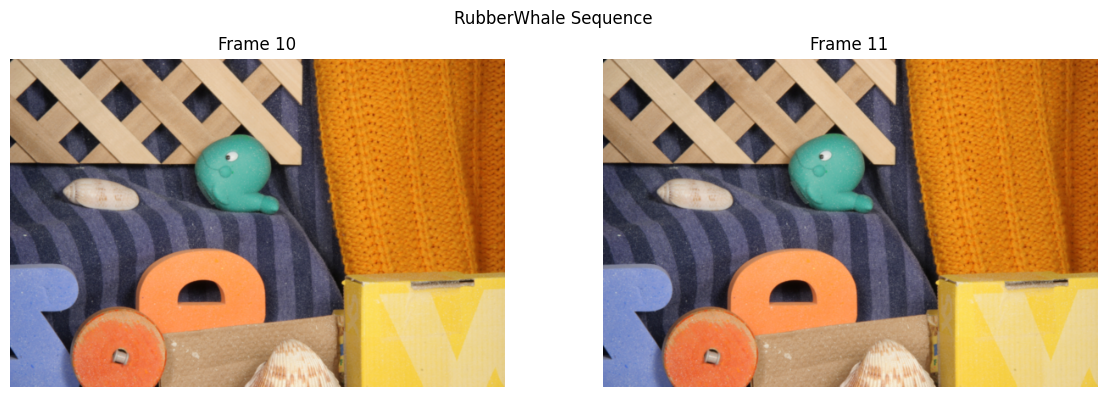

In [2]:
data_dir = os.path.join('..', 'data')
im1 = np.array(Image.open(os.path.join(data_dir, 'other-data', 'RubberWhale', 'frame10.png'))).astype(float)
im2 = np.array(Image.open(os.path.join(data_dir, 'other-data', 'RubberWhale', 'frame11.png'))).astype(float)
gt = read_flo(os.path.join(data_dir, 'other-gt-flow', 'RubberWhale', 'flow10.flo'))
tu, tv = gt[:, :, 0], gt[:, :, 1]

print(f'Image size: {im1.shape[1]} x {im1.shape[0]} x {im1.shape[2]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(im1.astype(np.uint8))
axes[0].set_title('Frame 10')
axes[0].axis('off')
axes[1].imshow(im2.astype(np.uint8))
axes[1].set_title('Frame 11')
axes[1].axis('off')
plt.suptitle('RubberWhale Sequence')
plt.tight_layout()
plt.show()

## RAFT: Recurrent All Pairs Field Transforms

RAFT (Teed & Deng, ECCV 2020) builds 4D correlation volumes from all pairs
of pixels and iteratively updates the flow field using a GRU-based update operator.

In [3]:
t0 = time.time()
uv_raft = estimate_flow(im1, im2, method='raft', params={'model_name': 'raft-things', 'iters': 20})

t_raft = time.time() - t0

aae_raft, _, aepe_raft = flow_angular_error(tu, tv, uv_raft[:, :, 0], uv_raft[:, :, 1], border=0)
print(f'RAFT: AAE {aae_raft:.3f}, EPE {aepe_raft:.3f}, Time {t_raft:.2f}s')

RAFT: AAE 6.049, EPE 0.185, Time 3.05s


## SEA-RAFT: Simple, Efficient, Accurate RAFT

SEA-RAFT (Wang, Lipson & Deng, ECCV 2024) improves RAFT with better
initialization, efficient attention, and a simplified architecture.

In [4]:
t0 = time.time()
uv_sea = estimate_flow(im1, im2, method='sea-raft', params={'model_name': 'sea-raft-things', 'iters': 20})
t_sea = time.time() - t0

aae_sea, _, aepe_sea = flow_angular_error(tu, tv, uv_sea[:, :, 0], uv_sea[:, :, 1], border=0)
print(f'SEA-RAFT: AAE {aae_sea:.3f}, EPE {aepe_sea:.3f}, Time {t_sea:.2f}s')

SEA-RAFT: AAE 4.097, EPE 0.124, Time 2.69s


## WAFT: Warping-Alone Field Transforms

WAFT (Wang & Deng, ICLR 2026) replaces cost volumes with high-resolution
warping, achieving state-of-the-art accuracy with up to 4.1x faster inference.
Currently ranked 1st on Spring, Sintel, and KITTI benchmarks.

In [5]:
t0 = time.time()
uv_waft = estimate_flow(im1, im2, method='waft', params={'model_name': 'waft-sintel', 'iters': 20})
t_waft = time.time() - t0

aae_waft, _, aepe_waft = flow_angular_error(tu, tv, uv_waft[:, :, 0], uv_waft[:, :, 1], border=0)
print(f'WAFT: AAE {aae_waft:.3f}, EPE {aepe_waft:.3f}, Time {t_waft:.2f}s')

xFormers not available
xFormers not available


WAFT: AAE 4.184, EPE 0.127, Time 3.30s


## Comparison: All Three Methods

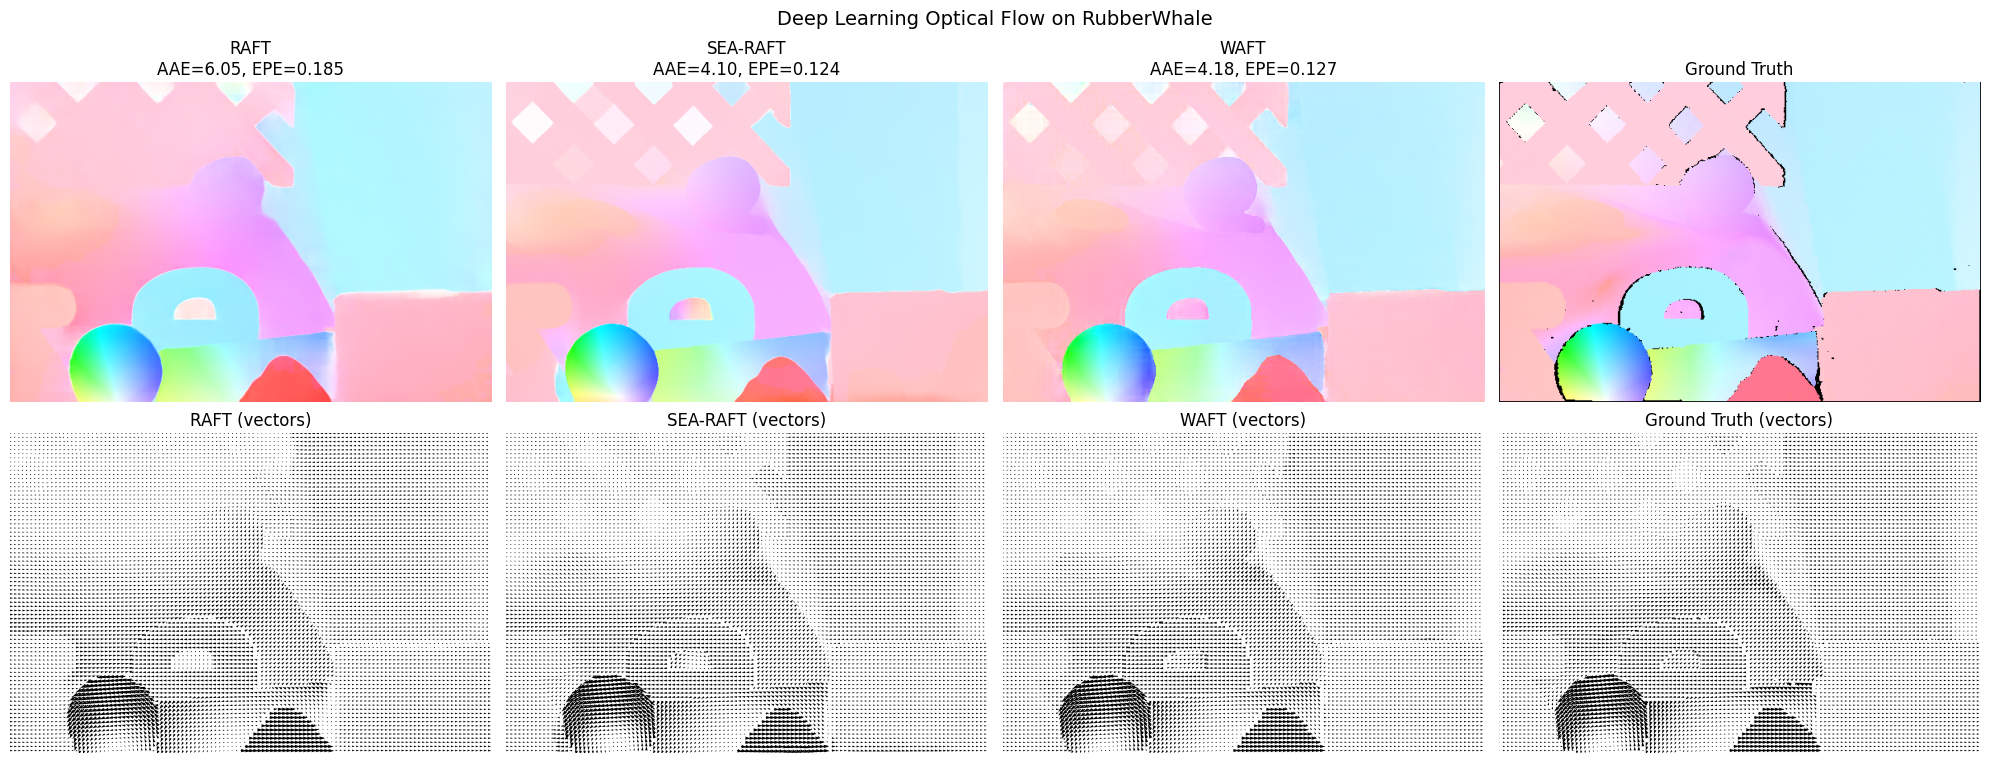

In [6]:
gt_flow = np.stack([tu, tv], axis=2)

methods = {
    'RAFT': uv_raft,
    'SEA-RAFT': uv_sea,
    'WAFT': uv_waft,
    'Ground Truth': gt_flow,
}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (name, uv) in enumerate(methods.items()):
    color_img = flow_to_color(uv)
    axes[0, i].imshow(color_img)
    if name != 'Ground Truth':
        aae, _, aepe = flow_angular_error(tu, tv, uv[:, :, 0], uv[:, :, 1], border=0)
        axes[0, i].set_title(f'{name}\nAAE={aae:.2f}, EPE={aepe:.3f}')
    else:
        axes[0, i].set_title(name)
    axes[0, i].axis('off')

    plot_flow(uv, style='quiver', ax=axes[1, i], step=5)
    axes[1, i].set_title(f'{name} (vectors)')

plt.suptitle('Deep Learning Optical Flow on RubberWhale', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

In [7]:
print(f'{"Method":<12} {"AAE":>8} {"EPE":>8} {"Time (s)":>10}')
print('-' * 42)
for name, aae, aepe, t in [
    ('RAFT', aae_raft, aepe_raft, t_raft),
    ('SEA-RAFT', aae_sea, aepe_sea, t_sea),
    ('WAFT', aae_waft, aepe_waft, t_waft),
]:
    print(f'{name:<12} {aae:>8.3f} {aepe:>8.3f} {t:>10.2f}')

Method            AAE      EPE   Time (s)
------------------------------------------
RAFT            6.049    0.185       3.05
SEA-RAFT        4.097    0.124       2.69
WAFT            4.184    0.127       3.30
